In [22]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from Model import ModelInterface


def make_dataset_graph_model(nodes_df:pd.DataFrame, edges_df:pd.DataFrame):
    nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
    nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.float))

    # Aggiungo nodi al grafo
    G = nx.Graph()
    for _, row in nodes_df.iterrows():
        num_id = int(row['num_id'])
        G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))

    edges_df['num_id_1'] = edges_df['num_id_1'].astype(int)
    edges_df['num_id_2'] = edges_df['num_id_2'].astype(int)
    edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.long)

    # Per visualizzazione debug
    G.add_edges_from(zip(edges_df['num_id_1'], edges_df['num_id_2']))

    data = Data(
        x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
        edge_index=edges,  # Edge list
        y=torch.stack([G.nodes[n]['y'] for n in G.nodes]),
        name= [G.nodes[n]['name'] for n in G.nodes]
    )

    # Escludendo le proteine in comune estrai un 10% per testing finale
    common_proteins_mask = np.array(["_AD" in name or "_PD" in name for name in data.name])
    non_common_indices = np.where(~common_proteins_mask)[0]

    num_test = int(0.1 * len(non_common_indices))
    final_test_indices = np.random.choice(non_common_indices, size=num_test, replace=False)
    final_test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    final_test_mask[final_test_indices] = True

    data.final_test_mask = final_test_mask
    data.kfold_usable_mask = ~(final_test_mask)

    return data, G

def make_dataset_traditional_model(nodes_df:pd.DataFrame, features='GO_embeddings'):
    nodes_df[features] = nodes_df[features].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
    nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.int))

    common_nodes = set(nodes_df[nodes_df['label'] == 2]['STRING_id'].to_list())
    nodes_df = nodes_df[~nodes_df['STRING_id'].isin(common_nodes)]

    G = nx.Graph()
    for _, row in nodes_df.iterrows():
        G.add_node(row['id'], x=row[features], y=torch.tensor(row['label'], dtype=torch.long))

    data = Data(
        x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
        y=torch.stack([G.nodes[n]['y'] for n in G.nodes])
    )

    return data, G

def train_multiple_times(Model: type[ModelInterface], num_iterations: int, data, lr=0.001, hidden_channels=64, out_channels=1, k_folds=5, epochs_per_fold=50):
    from tqdm import tqdm
    
    best_metrics_list = []

    with tqdm(total=num_iterations, desc="Training Progress", unit="iteration") as pbar:
        for _ in range(num_iterations):
            model = Model(in_channels=data.x.shape[1], hidden_channels=hidden_channels, out_channels=out_channels, dropout=0)

            _, best_metrics = model.k_fold_cross_validation(data, k=k_folds, epochs=epochs_per_fold, learning_rate=lr, patience=10)
            best_metrics_list.append(best_metrics)
            pbar.update(1)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    avg_metrics = {}
    std_metrics = {}
    for m in metrics:
        avg_metrics[m] = np.mean([metric[m] for metric in best_metrics_list], dtype='float64')
        std_metrics[m] = np.std([metric[m] for metric in best_metrics_list], dtype='float64')

    return avg_metrics

In [23]:
from MLP import MLP
from GraphSAGE import GCN_Sage
from GCN import GCN

mlp_emb_data, _ = make_dataset_traditional_model(
    pd.read_csv('../pre_processing_output/classification_three_labels_nodes_main_components.csv'))

mlp_sim_data, _ = make_dataset_traditional_model(
    pd.read_csv('../pre_processing_output/classification_three_labels_nodes_sim_main_components.csv'),
    features='features')

graph_nodes_emb_df = pd.read_csv("../pre_processing_output/duplicated_nodes_main_components.csv")

graph_nodes_sim_df = pd.read_csv("../pre_processing_output/duplicated_nodes_main_components_sim.csv")
graph_edges_df = pd.read_csv("../pre_processing_output/duplicated_edges_main_components.csv")
graph_edges_df2 = graph_edges_df.copy()

graph_emb_data, _ = make_dataset_graph_model(graph_nodes_emb_df, graph_edges_df)
graph_sim_data, _ = make_dataset_graph_model(graph_nodes_sim_df, graph_edges_df2)

training_schedule = {
    "GCN - emb": (GCN, graph_emb_data),
    "GCN - sim": (GCN, graph_sim_data),
    "GraphSAGE - emb": (GCN_Sage, graph_emb_data),
    "GraphSAGE - sim": (GCN_Sage, graph_sim_data),
    "MLP - emb": (MLP, mlp_emb_data),
    "MLP - sim": (MLP, mlp_sim_data)
}

results = dict()
for title, to_train in training_schedule.items():
    print(title)
    performances = train_multiple_times(to_train[0], 100, to_train[1])
    results[title] = performances

results_df = pd.DataFrame.from_dict(results, orient='index')

/tmp/ipykernel_50614/2284233897.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['id'], x=row[features], y=torch.tensor(row['label'], dtype=torch.long))
/tmp/ipykernel_50614/2284233897.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['id'], x=row[features], y=torch.tensor(row['label'], dtype=torch.long))
/tmp/ipykernel_50614/2284233897.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))


GCN - emb


Training Progress: 100%|██████████| 100/100 [02:02<00:00,  1.23s/iteration]


GCN - sim


Training Progress:   6%|▌         | 6/100 [00:07<01:48,  1.15s/iteration]/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Training Progress:  70%|███████   | 70/100 [01:16<00:33,  1.13s/iteration]/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Training Progress: 100%|██████████| 100/100 [01:49<00:00,  1.10s/iteration]


...

Training Progress: 100%|██████████| 100/100 [01:42<00:00,  1.03s/iteration]


MLP - emb


Training Progress: 100%|██████████| 100/100 [00:27<00:00,  3.63iteration/s]


MLP - sim


Training Progress: 100%|██████████| 100/100 [00:35<00:00,  2.83iteration/s]


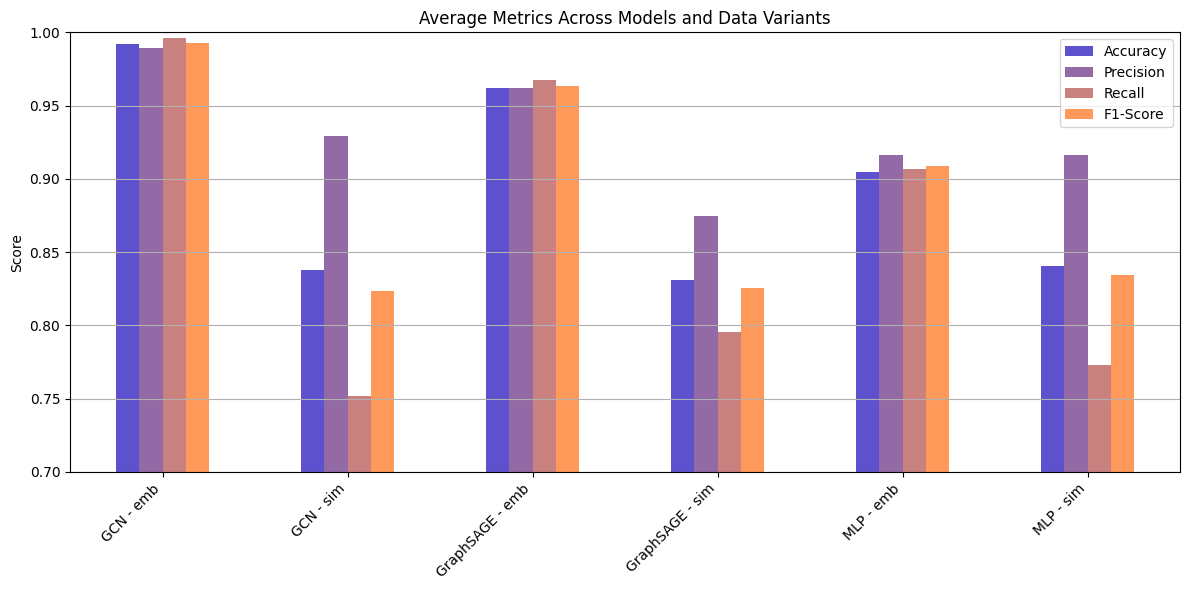

In [24]:
import matplotlib.colors as mcolors

def get_color_gradient(start_hex, end_hex, n):
    cmap = mcolors.LinearSegmentedColormap.from_list("grad", [start_hex, end_hex])
    return [mcolors.to_hex(cmap(i / (n - 1))) for i in range(n)]

ax = results_df.plot(kind='bar', figsize=(12, 6), color=get_color_gradient("#5D51CD", "#FF9959", 4))
ax.set_ylabel('Score')
ax.set_title('Average Metrics Across Models and Data Variants')
ax.set_ylim(0.7, 1.0)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()